In [3]:
import os
print(os.getcwd())
print(os.listdir())

/files
['.bashrc', 'README.md', 'AdvanceData', '.nuvolos', 'refresher']


In [4]:
import pandas as pd

constructor_standings = pd.read_csv('AdvanceData/data/constructor_standings.csv')
races = pd.read_csv('AdvanceData/data/races.csv')
constructors = pd.read_csv('AdvanceData/data/constructors.csv')

constructor_standings.head()


,constructorStandingsId,raceId,constructorId,points,position,positionText,wins
0,1,18,1,14.0,1,1,1
1,2,18,2,8.0,3,3,0
2,3,18,3,9.0,2,2,0
3,4,18,4,5.0,4,4,0
4,5,18,5,2.0,5,5,0


In [9]:
standings = constructor_standings.merge(races[['raceId', 'year', 'round']], on='raceId')

# for each team, in each year, keep only the last race (highest round) -> end-of-season standings
idx = standings.groupby(['year', 'constructorId'])['round'].idxmax()
final_standings = standings.loc[idx]

# restrict to the 2018-2024 window
final_standings = final_standings[(final_standings['year'] >= 2018) & (final_standings['year'] <= 2024)]

final_standings = final_standings.merge(constructors[['constructorId', 'name']], on='constructorId')
final_standings[['year', 'name', 'points', 'position']].sort_values(['year', 'position']).head(20)

,year,name,points,position
8,2018,Mercedes,655.0,1
4,2018,Ferrari,571.0,2
5,2018,Red Bull,419.0,3
2,2018,Renault,122.0,4
9,2018,Haas F1 Team,93.0,5
0,2018,McLaren,62.0,6
6,2018,Force India,52.0,7
7,2018,Sauber,48.0,8
3,2018,Toro Rosso,33.0,9
1,2018,Williams,7.0,10


In [6]:
gap_metrics = final_standings.groupby('year')['points'].agg(['std', 'min', 'max', 'mean']).round(1)
gap_metrics['range'] = gap_metrics['max'] - gap_metrics['min']
gap_metrics

,std,min,max,mean,range
year,,,,,
2018,244.7,7.0,655.0,206.2,648.0
2019,249.9,1.0,739.0,214.0,738.0
2020,174.8,0.0,573.0,171.9,573.0
2021,226.8,0.0,613.5,220.8,613.5
2022,270.8,8.0,759.0,235.0,751.0
2023,269.4,12.0,860.0,245.8,848.0
2024,288.0,4.0,666.0,265.9,662.0


In [7]:
races_per_year = races[races['year'].between(2018, 2024)].groupby('year')['round'].max()

gap_metrics = gap_metrics.merge(races_per_year.rename('num_races'), left_index=True, right_index=True)
gap_metrics['std_per_race'] = (gap_metrics['std'] / gap_metrics['num_races']).round(2)
gap_metrics['range_per_race'] = (gap_metrics['range'] / gap_metrics['num_races']).round(2)

gap_metrics[['num_races', 'std_per_race', 'range_per_race']]

,num_races,std_per_race,range_per_race
year,,,
2018,21,11.65,30.86
2019,21,11.90,35.14
2020,17,10.28,33.71
2021,22,10.31,27.89
2022,22,12.31,34.14
2023,22,12.25,38.55
2024,24,12.00,27.58


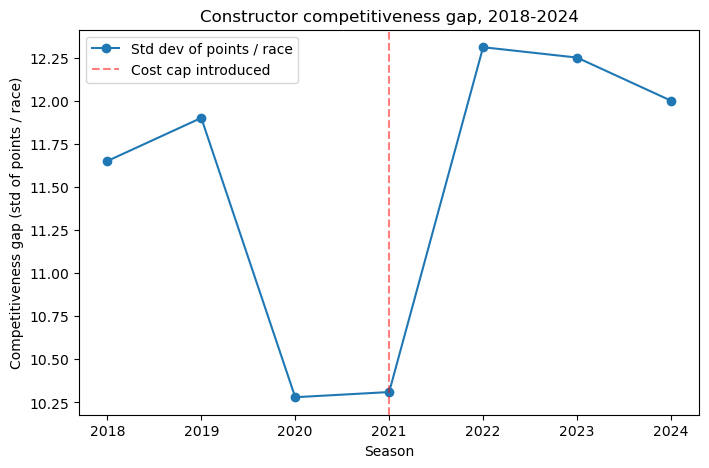

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gap_metrics.index, gap_metrics['std_per_race'], marker='o', label='Std dev of points / race')
ax.axvline(2021, color='red', linestyle='--', alpha=0.5, label='Cost cap introduced')
ax.set_xlabel('Season')
ax.set_ylabel('Competitiveness gap (std of points / race)')
ax.set_title('Constructor competitiveness gap, 2018-2024')
ax.legend()
plt.savefig('AdvanceData/figures/competitiveness_gap.png', dpi=150, bbox_inches='tight')
plt.show()